<a href="https://colab.research.google.com/github/akanshaj107/CitationIntentClassifier/blob/main/scibert_scicite_collab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Verify the GPU
Fine-tuning BERT-sized models on CPU is impractically slow. Confirm a GPU is attached.

In [1]:
!nvidia-smi

Thu May 28 09:31:19 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   58C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 2. Install dependencies

- `transformers` — Hugging Face library
- `datasets` — gives us SciCite dataset
- `scikit-learn` — F1, precision/recall, confusion matrix.
- `accelerate` — backend the `Trainer` uses to handle device placement / mixed precision.


In [2]:
!pip install -q -U transformers datasets scikit-learn accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 68.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 35.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 75.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 16.8 MB/s eta 0:00:00


## 3. Imports

In [3]:
import os
import random
import collections
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    set_seed,
)
from sklearn.metrics import (
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
set_seed(SEED)

print(f"torch={torch.__version__}, cuda={torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

torch=2.11.0+cu128, cuda=True
GPU: Tesla T4


## 4. Load SciCite

The dataset is published on the Hugging Face Hub by AllenAI. One call gives us three splits: `train`, `validation`, `test`.

Each example has fields including:
- `string` — the citation context (the sentence containing the citation). **This is the input.**
- `label` — one of `background`, `method`, `result`. **This is our target.**
- `sectionName`, `citingPaperId`, `citedPaperId`, etc. — extra metadata we ignore for the baseline.

In [4]:
from google.colab import files

uploaded = files.upload()

Saving dev.jsonl to dev.jsonl
Saving test.jsonl to test.jsonl
Saving train.jsonl to train.jsonl


## Load and Split Dataset

In [5]:
from datasets import load_dataset

dataset = load_dataset(
    "json",
    data_files={
        "train": "train.jsonl",
        "validation": "dev.jsonl",
        "test": "test.jsonl"
    }
)

print(dataset)


Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['source', 'citeEnd', 'sectionName', 'citeStart', 'string', 'label', 'label_confidence', 'citingPaperId', 'citedPaperId', 'isKeyCitation', 'id', 'unique_id', 'excerpt_index', 'label2', 'label2_confidence'],
        num_rows: 8243
    })
    validation: Dataset({
        features: ['source', 'citeEnd', 'sectionName', 'citeStart', 'string', 'label', 'label_confidence', 'citingPaperId', 'citedPaperId', 'isKeyCitation', 'id', 'unique_id', 'excerpt_index', 'label2', 'label2_confidence'],
        num_rows: 916
    })
    test: Dataset({
        features: ['source', 'citeEnd', 'sectionName', 'citeStart', 'string', 'label', 'label_confidence', 'citingPaperId', 'citedPaperId', 'isKeyCitation', 'id', 'unique_id', 'excerpt_index', 'label2', 'label2_confidence'],
        num_rows: 1861
    })
})


In [7]:
print("\nSample training example:")
print(dataset["train"][0])
print(set(dataset["train"]["label"]))


Sample training example:
{'source': 'explicit', 'citeEnd': 175.0, 'sectionName': 'Introduction', 'citeStart': 168.0, 'string': 'However, how frataxin interacts with the Fe-S cluster biosynthesis components remains unclear as direct one-to-one interactions with each component were reported (IscS [12,22], IscU/Isu1 [6,11,16] or ISD11/Isd11 [14,15]).', 'label': 'background', 'label_confidence': 1.0, 'citingPaperId': '1872080baa7d30ec8fb87be9a65358cd3a7fb649', 'citedPaperId': '894be9b4ea46a5c422e81ef3c241072d4c73fdc0', 'isKeyCitation': True, 'id': '1872080baa7d30ec8fb87be9a65358cd3a7fb649>894be9b4ea46a5c422e81ef3c241072d4c73fdc0', 'unique_id': '1872080baa7d30ec8fb87be9a65358cd3a7fb649>894be9b4ea46a5c422e81ef3c241072d4c73fdc0_11', 'excerpt_index': 11, 'label2': None, 'label2_confidence': None}
{'result', 'background', 'method'}


### 4a. Label distribution

Looking for class balance before training. SciCite is imbalanced.

In [8]:
for split in ["train", "validation", "test"]:
    counts = collections.Counter(dataset[split]["label"])
    total = sum(counts.values())
    pct = {k: f"{v} ({v/total:.1%})" for k, v in counts.items()}
    print(f"{split:>10}  (n={total}):  {pct}")

     train  (n=8243):  {'background': '4840 (58.7%)', 'method': '2294 (27.8%)', 'result': '1109 (13.5%)'}
validation  (n=916):  {'result': '123 (13.4%)', 'background': '538 (58.7%)', 'method': '255 (27.8%)'}
      test  (n=1861):  {'background': '997 (53.6%)', 'result': '259 (13.9%)', 'method': '605 (32.5%)'}


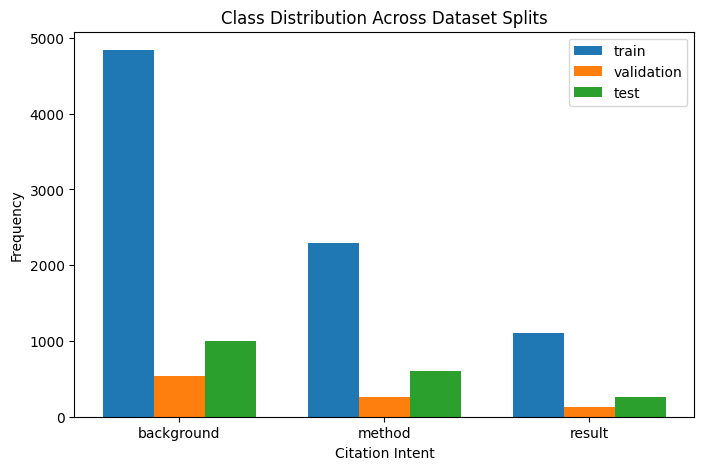

In [9]:
import matplotlib.pyplot as plt
import collections
import numpy as np

splits = ["train", "validation", "test"]
labels = ["background", "method", "result"]

x = np.arange(len(labels))
width = 0.25

plt.figure(figsize=(8,5))

for i, split in enumerate(splits):
    counts = collections.Counter(dataset[split]["label"])
    values = [counts[label] for label in labels]

    plt.bar(x + i*width, values, width=width, label=split)

plt.xticks(x + width, labels)
plt.xlabel("Citation Intent")
plt.ylabel("Frequency")
plt.title("Class Distribution Across Dataset Splits")
plt.legend()

plt.show()

## 5. Convert string labels to integer IDs

The model outputs logits over class indices `[0, 1, 2]`, so we need a fixed mapping.

In [14]:
label_list = ["background", "method", "result"]
label2id = {label: i for i, label in enumerate(label_list)}
id2label = {i: label for label, i in label2id.items()}

def encode_label(example):
    example["labels"] = label2id[example["label"]]
    return example

dataset = dataset.map(encode_label)
print(label2id)

Map:   0%|          | 0/8243 [00:00<?, ? examples/s]

Map:   0%|          | 0/916 [00:00<?, ? examples/s]

Map:   0%|          | 0/1861 [00:00<?, ? examples/s]

{'background': 0, 'method': 1, 'result': 2}


## 6. Tokenize with SciBERT's tokenizer

Using SciBERT's own tokenizer.
We use `allenai/scibert_scivocab_uncased`:
- `scivocab` — vocab built from scientific corpus (not BERT's original Wikipedia/Books vocab).
- `uncased` — lowercase.
- `max_length=256` comfortably covers SciCite citation contexts

In [15]:
MODEL_NAME = "allenai/scibert_scivocab_uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_fn(batch):
    return tokenizer(batch["string"], truncation=True, max_length=256)

tokenized_ds = dataset.map(tokenize_fn, batched=True)

# Keep only what the Trainer needs.
keep = {"input_ids", "attention_mask", "labels"}
drop = [c for c in tokenized_ds["train"].column_names if c not in keep]
tokenized_ds = tokenized_ds.remove_columns(drop)
tokenized_ds.set_format("torch")
print(tokenized_ds)

Map:   0%|          | 0/8243 [00:00<?, ? examples/s]

Map:   0%|          | 0/916 [00:00<?, ? examples/s]

Map:   0%|          | 0/1861 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 8243
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 916
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 1861
    })
})


## 7. Load SciBERT with a classification head

`AutoModelForSequenceClassification` does two things:
1. Loads the pretrained SciBERT encoder.
2. Attaches a fresh, randomly initialized linear layer on top of the `[CLS]` token's final hidden state, with `num_labels` outputs.

Theb missing indicates that some weights are newly initialized — that's the classification head, which is exactly what we train.

In [16]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_list),
    id2label=id2label,
    label2id=label2id,
)

pytorch_model.bin:   0%|          | 0.00/442M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: allenai/scibert_scivocab_uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those

## 8. Define the metric function

The paper reports **macro-F1** - because of class imbalance. We also log accuracy and macro precision/recall for context.

In [17]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="macro", zero_division=0
    )
    return {
        "accuracy": (preds == labels).mean(),
        "macro_f1": f1,
        "macro_precision": precision,
        "macro_recall": recall,
    }

## 9. Training configuration

Standard BERT fine-tuning hyperparameters — these are the values from the SciBERT paper (Beltagy et al., 2019) and HF defaults:

| Setting | Value | Why |
|---|---|---|
| Learning rate | `2e-5` | Standard small LR for BERT fine-tuning; larger LRs cause catastrophic forgetting. |
| Batch size (train) | 32 | Fits on a free T4. If OOM, drop to 16. |
| Epochs | 4 | SciBERT converges fast on SciCite; more usually overfits. |
| Weight decay | 0.01 | Mild regularization, standard for BERT. |
| Warmup steps | 100 | LR ramps up over first 10% of steps to stabilize early training. |
| `load_best_model_at_end` | `True` | Picks the checkpoint with the best validation macro-F1, not the last one. |

We evaluate every epoch and select on macro-F1.

In [18]:
training_args = TrainingArguments(
    output_dir="./scibert-scicite",
    num_train_epochs=4,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_steps=100,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    logging_steps=50,
    save_total_limit=2,
    fp16=torch.cuda.is_available(),
    report_to="none",
    seed=SEED,
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_ds["train"],
    eval_dataset=tokenized_ds["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

## 10. Train


In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Macro Precision,Macro Recall
1,0.419166,0.428599,0.830786,0.809011,0.793294,0.831984
2,0.291443,0.468134,0.848253,0.823278,0.839619,0.816318
3,0.166414,0.503436,0.855895,0.834897,0.835804,0.835095


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

## 11. Evaluate on test dataset




In [20]:
test_metrics = trainer.evaluate(tokenized_ds["test"])
for k, v in test_metrics.items():
    print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")

Training Loss,Validation Loss,Epoch,Accuracy,Macro F1,Macro Precision,Macro Recall
0.124454,0.464953,4,0.859753,0.844895,0.829547,0.869295


eval_loss: 0.4650
eval_accuracy: 0.8598
eval_macro_f1: 0.8449
eval_macro_precision: 0.8295
eval_macro_recall: 0.8693


### 11a. Per-class breakdown


In [21]:
predictions = trainer.predict(tokenized_ds["test"])
y_pred = np.argmax(predictions.predictions, axis=-1)
y_true = predictions.label_ids

print(classification_report(y_true, y_pred, target_names=label_list, digits=4))

              precision    recall  f1-score   support

  background     0.8991    0.8576    0.8778       997
      method     0.8839    0.8430    0.8629       605
      result     0.7057    0.9073    0.7939       259

    accuracy                         0.8598      1861
   macro avg     0.8295    0.8693    0.8449      1861
weighted avg     0.8672    0.8598    0.8613      1861



### 11b. Confusion matrix

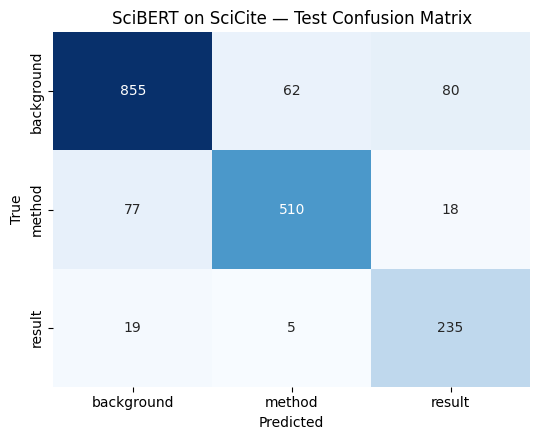

In [22]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=label_list, yticklabels=label_list, cbar=False
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("SciBERT on SciCite — Test Confusion Matrix")
plt.tight_layout()
plt.show()

## 12. Inference on custom citation
Sanity-check the trained model on hand-crafted examples.

In [23]:
device = next(model.parameters()).device
model.eval()

def predict_intent(text):
    inputs = tokenizer(text, truncation=True, max_length=256, return_tensors="pt").to(device)
    with torch.no_grad():
        logits = model(**inputs).logits[0]
    probs = torch.softmax(logits, dim=-1)
    pred = id2label[int(probs.argmax())]
    return pred, {id2label[i]: float(probs[i]) for i in range(len(label_list))}

examples = [

    "We use the BERT model proposed by Devlin et al. (2019) as our base encoder.",

    "Citation intent classification has been studied for over a decade (Teufel et al., 2006).",

    "Our F1 score of 0.84 is consistent with the results reported by Cohan et al. (2019).",

    "Following the standard pipeline of Smith et al. (2020), we preprocess the corpus before training.",
]

for ex in examples:
    pred, probs = predict_intent(ex)
    probs_str = ", ".join(f"{k}={v:.2f}" for k, v in probs.items())
    print(f"[{pred:<10}]  {ex}\n           {probs_str}\n")

[method    ]  We use the BERT model proposed by Devlin et al. (2019) as our base encoder.
           background=0.00, method=0.99, result=0.00

[background]  Citation intent classification has been studied for over a decade (Teufel et al., 2006).
           background=0.99, method=0.01, result=0.00

[result    ]  Our F1 score of 0.84 is consistent with the results reported by Cohan et al. (2019).
           background=0.00, method=0.00, result=0.99

[method    ]  Following the standard pipeline of Smith et al. (2020), we preprocess the corpus before training.
           background=0.01, method=0.99, result=0.00



## 13. Save the final model
Persists the encoder, classification head, tokenizer, and label mappings together. It can be reloaded with `AutoModelForSequenceClassification.from_pretrained("./scibert-scicite-final")` later.

In [24]:
trainer.save_model("./scibert-scicite-final")
tokenizer.save_pretrained("./scibert-scicite-final")
print("Saved to ./scibert-scicite-final")

# Optional: download as a zip from Colab
# !zip -r scibert-scicite-final.zip scibert-scicite-final
# from google.colab import files
# files.download('scibert-scicite-final.zip')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to ./scibert-scicite-final
